# Final project: Hotel star rating analysis

Dania, Isabel, Ruichi, Toma
## Part 1: Introduction

We study hotel listings where star ratings, geography, and text-derived amenities appear alongside city-level context. After cleaning and joining hotel records to a world-cities table, we obtain a single analysis-ready table (`hotels_with_cities`) whose rows are hotels and whose columns include parsed **star ratings**, coordinates, amenity counts, and **city population** where the join succeeds.

**Goal of this notebook:** document how the data were prepared, summarize **data quality and the rating distribution**, and spell out **issues that affect modeling** (missing labels, join coverage, imbalance). **Part 5** onward trains and compares regressors; **Parts 1–4** set up the story and constraints for those models.

**How this notebook is organized**
- **Part 2** — How to run the repo locally, what the cleaning pipeline does, and definitions of engineered fields.
- **Part 3** — Load the processed Parquet and inspect size, missingness, and star-rating counts.
- **Part 4** — Interpret those summaries for modeling (before any training runs).
- **Part 5** — Regression models, hyperparameter tuning, permutation-based hypothesis checks, and optional XGBoost setup notes.
- **Parts 6–7** — Further exploratory analysis and visualizations.


In [ ]:
# Ensure imports work when running locally.
# Run this notebook from the repo root (the folder that contains `src/` and `data/`).

import sys
from pathlib import Path

PROJECT = Path.cwd()
sys.path.insert(0, str(PROJECT))

import src
print("Imported src from:", Path(src.__file__).resolve())

In [ ]:
# Install project requirements (local)
# If you already have dependencies installed, you can skip this.
# Copied from requirements.txt:
# pandas>=2.0
# country_converter>=1.0
# pyarrow>=14.0
# scikit-learn>=1.3
# xgboost

!python3 -m pip install -q "pandas>=2.0" "country_converter>=1.0" "pyarrow>=14.0" "scikit-learn>=1.3" "xgboost"

## Part 2: Environment, pipeline, and engineered features

### 2.1 Running this notebook locally

Open Jupyter **from the repository root** (the directory that contains `src/`, `data/`, `scripts/`, and `requirements.txt`). The next cells put the project on `sys.path` and optionally install packages from `requirements.txt` so `import src` and relative paths work.

**Paths used in this analysis:**
- Raw inputs: `data/raw/`
- Processed joined table used below: `data/processed/hotels_with_cities-2.parquet`

### 2.2 What the wrangling pipeline does

Implementation lives in `src/` and is also exposed via `scripts/pipeline/run_cleaning.py`. In order, it:
- **Cleans and standardizes** the raw hotel and world-cities files
- **Builds engineered columns** used in exploration and modeling
- **Joins** each hotel to a city row and adds **`city_population`** when the keys match
- **Writes** processed outputs under `data/processed/`

### 2.3 Engineered fields (definition)

| Field | Description |
|-------|-------------|
| `hotel_star_rating` | Parsed from `HotelRating` into a numeric **1–5** label (target for regression). |
| `hotel_latitude`, `hotel_longitude` | Parsed from `Map` (stored as lat/lon). |
| `attractions_count` | Count derived from the `Attractions` text. |
| `facilities_count` | Token count from `HotelFacilities` (rough length of the amenities list). |
| `facilities_keyword_hits` | Number of curated amenity keywords found in `HotelFacilities`. |
| `city_population` | Population from the world-cities table, joined on `country_iso2` and `city_join_key`. |

For this submission we assume **`data/processed/hotels_with_cities-2.parquet`** is already built. The following code cell can **regenerate** processed outputs from `data/raw/` by setting `RUN_CLEANING = True` (can be slow); the usual workflow keeps `RUN_CLEANING = False`.


In [ ]:
# Optional: regenerate the processed datasets *in-notebook*.
# Normal workflow: keep this False and just load the already-built Parquet.

from pathlib import Path

RUN_CLEANING = False

if RUN_CLEANING:
    from src.cleaning.hotel_world_clean import run_cleaning_pipeline

    written = run_cleaning_pipeline(
        output_dir=Path("data/processed"),
        output_format="parquet",
        # Chunking keeps long runs from feeling "stuck".
        hotels_chunksize=50_000,
        progress_every_rows=50_000,
        also_join=True,
    )

    for label, path in written.items():
        print(f"{label}: {path}")
else:
    print("Skipping cleaning pipeline (processed dataset already exists).")

## Part 3: Loading and inspecting the processed dataset

We load the joined Parquet to confirm the file is present, to see **scale and schema**, and to measure **missingness** and the **distribution of `hotel_star_rating`**. This is our main exploratory snapshot before fitting models.

**The next code cell prints and displays:**
- **Shape** — row count and number of columns
- **Preview** — first five rows so the TA can see example records
- **Missingness** — the twelve columns with the highest **% missing** (join and parsing gaps show up here)
- **Star rating counts** — frequency table of `hotel_star_rating` (including missing), showing imbalance across 1–5 stars


In [ ]:
from pathlib import Path
import pandas as pd

joined = Path("data/processed/hotels_with_cities-2.parquet")
if not joined.is_file():
    raise FileNotFoundError(
        f"Expected processed Parquet at {joined}. "
        "If you saved it under a different name/location, update the path here."
    )

df = pd.read_parquet(joined)

# Normalize any alias column names to the canonical schema.
try:
    from src.modeling.feature_matrix import normalize_engineered_column_names

    df = normalize_engineered_column_names(df)
except Exception:
    pass

print("processed Parquet:", joined)
print("rows:", len(df), "cols:", df.shape[1])

display(df.head(5))

na_rate = (df.isna().mean() * 100).sort_values(ascending=False)
display(na_rate.head(12).to_frame(name="% missing"))

if "hotel_star_rating" not in df.columns:
    raise KeyError("Expected column 'hotel_star_rating' not found in processed dataset.")

display(df["hotel_star_rating"].value_counts(dropna=False).sort_index().to_frame(name="count"))

## Part 4: Findings and implications (before modeling)

These points summarize what Part 3 showed and **why they matter** for the modeling section later.

**Join coverage (`city_population`):** Population is missing for **about 65%** of rows in our processed table. The city join is informative where it hits but is **not universal**—we should treat `city_population` as **partially observed** (imputation, a missingness indicator, or dropping the feature are all reasonable depending on validation performance and leakage concerns).

**Target availability (`hotel_star_rating`):** The star rating is missing on **roughly 31%** of rows (**about 316k** rows in this dataset). Standard supervised regression uses only rows with a known rating; rows without a label are excluded unless we change the task.

**Imbalance across star levels:** Counts are largest near **3★ and 2★**; **5★** is much less frequent (**about 22k** rows in our run). Predictions may cluster toward the middle of the scale unless the model and metrics account for **error at the tails** (e.g. reporting accuracy within 0.5 or 1.0 stars, or errors by rating bucket).

**Takeaway:** Expect modeling sections to use a **train/test split**, compare several algorithms, and interpret **RMSE/MAE/R²** together with **hit rates**—a single headline number can hide poor performance on rare high-star hotels.


## Part 5: Modeling

This section trains and compares multiple regression models for hotel rating prediction.

Supported models:
- `linear`, `ridge`, `lasso`, `rf`, `xgb`

Metrics reported:
- RMSE, MAE, R²
- hit rates: `|error| <= 0.5` and `|error| <= 1.0`


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()
OUT_DIR = Path("outputs/model_artifacts_local")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Use a sample for speed while iterating. Set to None for full dataset.
SAMPLE_ROWS = 100_000
RANDOM_STATE = 42

print("project root:", PROJECT_ROOT)
print("artifacts dir:", OUT_DIR)
print("sample rows:", SAMPLE_ROWS)


In [ ]:
# Train two baseline models (fast examples).
# This writes metrics.json and model artifacts under OUT_DIR.

sample_arg = [] if SAMPLE_ROWS is None else ["--sample", str(SAMPLE_ROWS)]

!python3 scripts/modeling/train_baseline_model.py --project-root "{PROJECT_ROOT}" --model linear --out-dir "{OUT_DIR / 'linear'}" --random-state {RANDOM_STATE} {*sample_arg}
!python3 scripts/modeling/train_baseline_model.py --project-root "{PROJECT_ROOT}" --model rf --out-dir "{OUT_DIR / 'rf'}" --random-state {RANDOM_STATE} {*sample_arg}


In [ ]:
# Run a small comparison set and summarize metrics.

import json
import subprocess
import pandas as pd

RUNS_DIR = OUT_DIR / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

models_to_run = [
    ("linear", []),
    ("ridge", ["--ridge-alpha", "10"]),
    ("lasso", ["--lasso-alpha", "0.001"]),
    ("rf", ["--rf-estimators", "200", "--rf-max-depth", "20"]),
]

for model_name, extra_args in models_to_run:
    out_dir = RUNS_DIR / model_name
    out_dir.mkdir(parents=True, exist_ok=True)
    cmd = [
        "python3",
        "scripts/modeling/train_baseline_model.py",
        "--project-root",
        str(PROJECT_ROOT),
        "--model",
        model_name,
        "--out-dir",
        str(out_dir),
        "--random-state",
        str(RANDOM_STATE),
    ]
    if SAMPLE_ROWS is not None:
        cmd.extend(["--sample", str(SAMPLE_ROWS)])
    cmd.extend(extra_args)

    print("Running:", " ".join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)

summary_rows = []
for model_name, _ in models_to_run:
    metrics_path = RUNS_DIR / model_name / "metrics.json"
    if not metrics_path.exists():
        continue
    metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
    summary_rows.append(
        {
            "model": model_name,
            "rows": metrics["rows"],
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
            "within_0_5": metrics["within_0_5"],
            "within_1_0": metrics["within_1_0"],
            "tuned": metrics.get("tuned", False),
        }
    )

results_df = pd.DataFrame(summary_rows).sort_values(by="rmse", ascending=True)
results_df

### 5.1 Hyperparameter tuning (model assessment)

To satisfy model-assessment requirements, we run tuned versions of selected models.

- `ridge` uses `RidgeCV`
- `rf` and `xgb` use `RandomizedSearchCV`
- tuning objective: `neg_root_mean_squared_error`

Tip: keep `--tune-iters` small while iterating, then increase for final runs.

In [ ]:
# Run tuned models (cross-validated search)

tuned_jobs = [
    ("ridge", ["--tune", "--cv-folds", "3"]),
    ("rf", ["--tune", "--cv-folds", "3", "--tune-iters", "12"]),
    ("xgb", ["--tune", "--cv-folds", "3", "--tune-iters", "12"]),
]

for model_name, tune_args in tuned_jobs:
    out_dir = RUNS_DIR / f"{model_name}_tuned"
    out_dir.mkdir(parents=True, exist_ok=True)
    cmd = [
        "python3",
        "scripts/modeling/train_baseline_model.py",
        "--project-root",
        str(PROJECT_ROOT),
        "--model",
        model_name,
        "--out-dir",
        str(out_dir),
        "--random-state",
        str(RANDOM_STATE),
    ]
    if SAMPLE_ROWS is not None:
        cmd.extend(["--sample", str(SAMPLE_ROWS)])
    cmd.extend(tune_args)

    print("Running tuned:", " ".join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)

print("Tuned runs completed.")

In [ ]:
# Compare untuned vs tuned results

all_rows = []
for p in sorted(RUNS_DIR.glob("*/metrics.json")):
    m = json.loads(p.read_text(encoding="utf-8"))
    all_rows.append(
        {
            "run": p.parent.name,
            "model": m["model"],
            "rmse": m["rmse"],
            "mae": m["mae"],
            "r2": m["r2"],
            "within_0_5": m["within_0_5"],
            "within_1_0": m["within_1_0"],
            "tuned": m.get("tuned", False),
            "best_params": m.get("best_params", {}),
        }
    )

comparison_df = pd.DataFrame(all_rows).sort_values(by="rmse", ascending=True)
comparison_df

### 5.2 Hypothesis testing (permutation-based)

This runs a simulation-based test to check whether observed relationships for selected features are stronger than chance (correlation evidence, not causation).


In [ ]:
import subprocess
from pathlib import Path

hypo_out = OUT_DIR / "hypothesis_tests.json"
cmd = [
    "python3",
    "scripts/modeling/permutation_hypothesis_tests.py",
    "--project-root",
    str(PROJECT_ROOT),
    "--out",
    str(hypo_out),
    "--n-permutations",
    "200",
    "--random-state",
    str(RANDOM_STATE),
]
if SAMPLE_ROWS is not None:
    cmd.extend(["--sample", str(SAMPLE_ROWS)])

print("Running:", " ".join(cmd))
subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)
print("Wrote:", hypo_out)


### 5.3 Optional: XGBoost (local note)

On macOS, XGBoost often requires the OpenMP runtime (**OpenMP `libomp`**).

If you see an error about `libomp.dylib` missing, install it and reinstall XGBoost:

- `brew install libomp`
- restart your terminal/kernel
- `python3 -m pip install -U xgboost`

If XGBoost is not available locally, you can still run `linear`, `ridge`, `lasso`, and `rf` here, and run `xgb` in Kaggle.


In [ ]:
# Optional local XGBoost run (guarded).

RUN_XGB = False

if RUN_XGB:
    try:
        import xgboost  # noqa: F401

        print("xgboost available")
    except Exception as e:
        raise RuntimeError(
            "xgboost is not available locally. On macOS, install OpenMP runtime (libomp) then reinstall xgboost."
        ) from e

    import subprocess

    out_dir = RUNS_DIR / "xgb"
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        "python3",
        "scripts/modeling/train_baseline_model.py",
        "--project-root",
        str(PROJECT_ROOT),
        "--model",
        "xgb",
        "--out-dir",
        str(out_dir),
        "--random-state",
        str(RANDOM_STATE),
        "--xgb-estimators",
        "300",
        "--xgb-max-depth",
        "8",
        "--xgb-learning-rate",
        "0.05",
    ]
    if SAMPLE_ROWS is not None:
        cmd.extend(["--sample", str(SAMPLE_ROWS)])

    print("Running:", " ".join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)
else:
    print("RUN_XGB is False — skipping XGBoost locally.")


## Part 6: Exploratory Data Analysis


*Insights in this section are adapted from the standalone EDA notebook (`scripts/EDA/eda_notebook_local.ipynb`). Each figure is followed by a short interpretation.*


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_parquet('../data/processed/hotels_with_cities-2.parquet')

# --- 1. Refined Sub-Region Mapping ---
region_map = {
    # NORTH AMERICA
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',

    # SOUTH AMERICA
    'Argentina': 'South America', 'Bolivia': 'South America', 'Brazil': 'South America',
    'Chile': 'South America', 'Colombia': 'South America', 'Ecuador': 'South America',
    'Paraguay': 'South America', 'Peru': 'South America', 'Uruguay': 'South America',
    'Venezuela': 'South America',

    # CENTRAL AMERICA & CARIBBEAN
    'Antigua': 'Central America/Caribbean', 'Aruba': 'Central America/Caribbean', 'Bahamas': 'Central America/Caribbean',
    'Barbados': 'Central America/Caribbean', 'Costa Rica': 'Central America/Caribbean', 'Dominican Republic': 'Central America/Caribbean',
    'Grenada': 'Central America/Caribbean', 'Guadeloupe': 'Central America/Caribbean', 'Guatemala': 'Central America/Caribbean',
    'Jamaica': 'Central America/Caribbean', 'Panama': 'Central America/Caribbean', 'Puerto Rico': 'Central America/Caribbean',
    'St Kitts & Nevis': 'Central America/Caribbean', 'St Lucia': 'Central America/Caribbean',
    'St Vincent & Grenadi': 'Central America/Caribbean', 'Trinidad & Tobago': 'Central America/Caribbean',
    'Turks & Caicos Islan': 'Central America/Caribbean', 'Virgin Islands (USA)': 'Central America/Caribbean',

    # EAST ASIA
    'China': 'East Asia', 'Hong Kong': 'East Asia', 'Japan': 'East Asia',
    'Macau': 'East Asia', 'Mongolia': 'East Asia', 'South Korea': 'East Asia', 'Taiwan': 'East Asia',

    # SOUTHEAST ASIA
    'Brunei Darussalam': 'Southeast Asia', 'Cambodia': 'Southeast Asia', 'Indonesia': 'Southeast Asia',
    'Laos': 'Southeast Asia', 'Malaysia': 'Southeast Asia', 'Myanmar': 'Southeast Asia',
    'Philippines': 'Southeast Asia', 'Singapore': 'Southeast Asia', 'Thailand': 'Southeast Asia',
    'Vietnam': 'Southeast Asia',

    # SOUTH ASIA
    'India': 'South Asia', 'Nepal': 'South Asia', 'Sri Lanka': 'South Asia',

    # MIDDLE EAST
    'Bahrain': 'Middle East', 'Israel': 'Middle East', 'Jordan': 'Middle East', 'Kuwait': 'Middle East',
    'Lebanon': 'Middle East', 'Oman': 'Middle East', 'Qatar': 'Middle East', 'Saudi Arabia': 'Middle East',
    'Turkey': 'Middle East', 'United Arab Emirates': 'Middle East', 'Yemen Republic': 'Middle East',

    # EUROPE
    'Albania': 'Europe', 'Andorra': 'Europe', 'Austria': 'Europe', 'Azerbaijan': 'Europe',
    'Belarus': 'Europe', 'Belgium': 'Europe', 'Bosnia Herzegovina': 'Europe', 'Bulgaria': 'Europe',
    'Croatia': 'Europe', 'Cyprus': 'Europe', 'Czech Republic': 'Europe', 'Denmark': 'Europe',
    'Estonia': 'Europe', 'Finland': 'Europe', 'France': 'Europe', 'Germany': 'Europe',
    'Gibraltar': 'Europe', 'Greece': 'Europe', 'Hungary': 'Europe', 'Iceland': 'Europe',
    'Ireland(Republic of)': 'Europe', 'Italy': 'Europe', 'Latvia': 'Europe', 'Liechtenstein': 'Europe',
    'Lithuania': 'Europe', 'Luxembourg': 'Europe', 'Malta': 'Europe', 'Monaco': 'Europe',
    'Netherlands': 'Europe', 'Norway': 'Europe', 'Poland': 'Europe', 'Portugal': 'Europe',
    'Romania': 'Europe', 'Russia': 'Europe', 'Russian Federation': 'Europe', 'San Marino': 'Europe',
    'Serbia': 'Europe', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Spain': 'Europe',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'Ukraine': 'Europe', 'United Kingdom': 'Europe',

    # AFRICA
    'Botswana': 'Africa', 'Cameroon': 'Africa', 'Egypt': 'Africa', 'Ethiopia': 'Africa',
    'Kenya': 'Africa', 'Libya': 'Africa', 'Mauritius': 'Africa', 'Morocco': 'Africa',
    'Namibia': 'Africa', 'Nigeria': 'Africa', 'Senegal': 'Africa', 'Seychelles': 'Africa',
    'South Africa': 'Africa', 'Tanzania': 'Africa', 'Tunisia': 'Africa', 'Zambia': 'Africa',
    'Zimbabwe': 'Africa', 'Swaziland': 'Africa',

    # OCEANIA
    'Australia': 'Oceania', 'Cook Islands': 'Oceania', 'Fiji': 'Oceania', 'Guam': 'Oceania',
    'New Caledonia': 'Oceania', 'New Zealand': 'Oceania', 'Northern Mariana Isl': 'Oceania',
    'Palau': 'Oceania', 'Samoa': 'Oceania', 'Tonga': 'Oceania', 'Vanuatu': 'Oceania',
    'French Polynesia': 'Oceania'
}

# --- Map Sub-Regions to Main Continents ---
continent_map = {
    'North America': 'North America',
    'South America': 'South America',
    'Central America/Caribbean': 'North America',
    'East Asia': 'Asia',
    'Southeast Asia': 'Asia',
    'South Asia': 'Asia',
    'Middle East': 'Asia',
    'Europe': 'Europe',
    'Africa': 'Africa',
    'Oceania': 'Oceania'
}

df['sub_region'] = df['countyName'].map(region_map).fillna('Other')
df['continent'] = df['sub_region'].map(continent_map).fillna('Other')

# Global styling
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# --- 2. Calculations ---
sub_region_stats = df.groupby('sub_region')['hotel_star_rating'].mean().sort_values(ascending=False)
continent_stats = df.groupby('continent')['hotel_star_rating'].mean().sort_values(ascending=False)
country_stats = df.groupby('countyName')['hotel_star_rating'].mean().dropna()
city_stats = df.groupby(['cityName', 'countyName'])['hotel_star_rating'].agg(['mean', 'count']).dropna().reset_index()
city_stats['city_label'] = city_stats['cityName'] + " (" + city_stats['countyName'] + ")"

reliable_cities = city_stats[city_stats['count'] >= 10]

top_10_countries = country_stats.sort_values(ascending=False).head(10)
worst_10_countries = country_stats.sort_values(ascending=True).head(10)
top_10_cities = reliable_cities.sort_values(by='mean', ascending=False).head(10)
worst_10_cities = reliable_cities.sort_values(by='mean', ascending=True).head(10)


### Interpretation — Figure 1
At first, we check the distribution of the hotel rating because it allows us to assess the variance and balance of the data, ensuring that the ratings are not heavily skewed toward a specific score.
About Figure 1 and the distribution of hotel ratings, while it was initially expected that hotel ratings would cluster between 3 and 5 stars which would have resulted in limited variance, Figure 1 shows that the actual distribution is almost symmetric and follows a bell shaped curve centered at 3. This symmetry indicates that the dataset is highly balanced and representative of the global market. Because the ratings are not skewed toward a specific quality level, the data provides a reliable baseline where the mid range experience is the most common, and extreme budget or luxury options exist as equally distributed outliers.

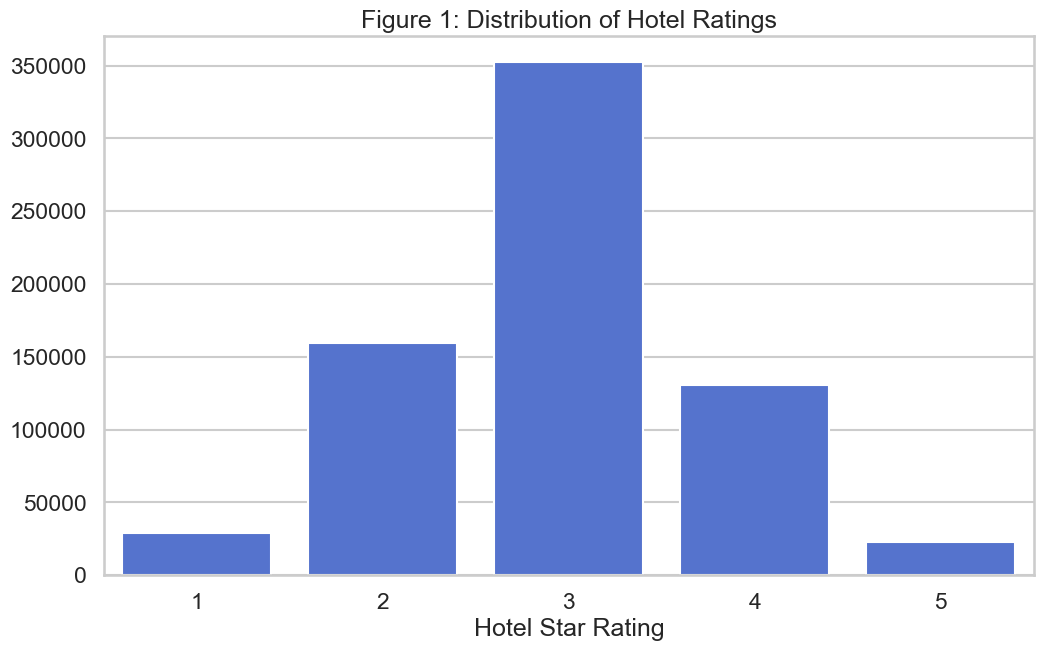

In [2]:
# Figure 1: Distribution
plt.figure()
sns.countplot(data=df, x='hotel_star_rating', color='royalblue')
plt.title('Figure 1: Distribution of Hotel Ratings')
plt.xlabel('Hotel Star Rating')
plt.ylabel('')
plt.show()


### Interpretation — Figure 2

Next, we check all potential correlations between hotel star ratings and external metrics such as city population, surrounding attractions, facility counts, and geographical location. We perform this step to identify the key drivers of hotel quality and determine whether a hotel's rating is primarily influenced by its internal service standards or its external environment.
Figure 2 shows that there is not much of a clear trend between hotel ratings and population. The results demonstrate that both 2 star and 5 star hotels are located in the largest metropolitan areas with averages over 1 million residents. Meanwhile, the figures for 3 star and 4 star hotels show a lower average population which indicates these categories do not follow a simple upward trajectory. The 1 star rating is associated with the lowest average population but the overall lack of a consistent pattern suggests that population is not a strong predictor for hotel quality levels in this dataset.

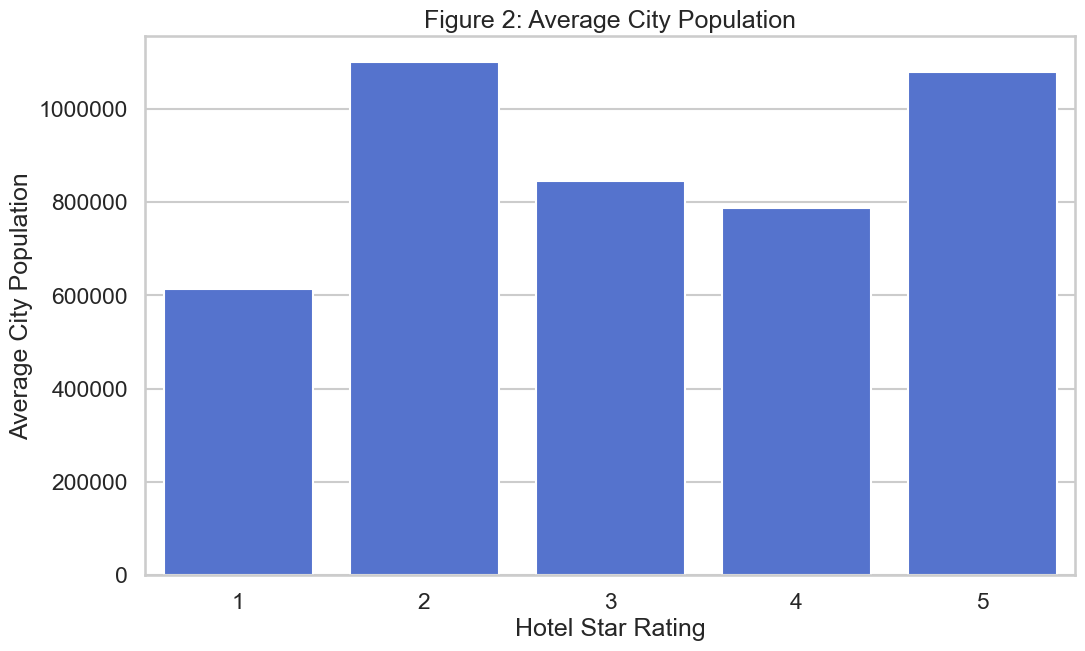

In [3]:
# Figure 2
plt.figure()
sns.barplot(data=df, x='hotel_star_rating', y='city_population', estimator=np.mean, errorbar=None, color='royalblue')

plt.ticklabel_format(style='plain', axis='y')
plt.title('Figure 2: Average City Population')
plt.xlabel('Hotel Star Rating')
plt.ylabel('Average City Population')
plt.show()


### Interpretation — Figure 3

Figure 3 shows that there is not much of a clear trend between hotel ratings and attraction counts. The results reveal that 2 star and 3 star hotels are located in areas with the highest average attraction counts, exceeding 10.00 per city. Meanwhile, the figures for 4 star and 5 star hotels show a lower average count, which indicates these categories do not follow a simple upward trajectory. The 1 star rating is associated with the lowest average attraction count of 6.78, but the overall lack of a consistent pattern suggests that attraction density is not a strong predictor for hotel quality levels in this dataset.

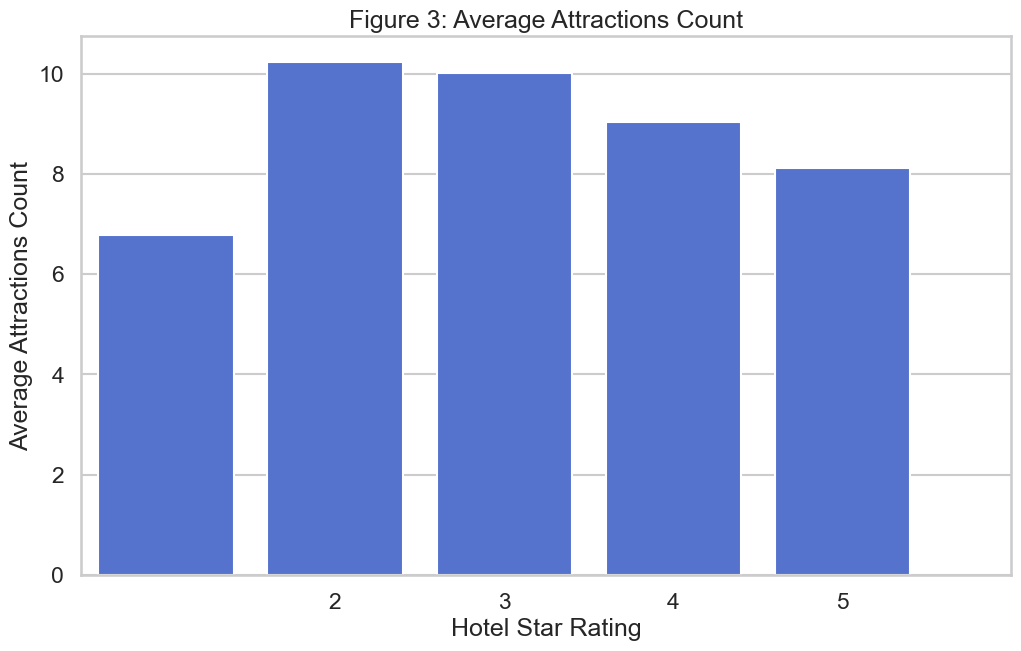

In [21]:
# Figure 3
plt.figure()
sns.barplot(data=df, x='hotel_star_rating', y='attractions_count', estimator=np.mean, errorbar=None, color='royalblue')
plt.title('Figure 3: Average Attractions Count')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel('Hotel Star Rating')
plt.ylabel('Average Attractions Count')
plt.show()


### Interpretation — Figure 4

Figure 4a reveals a clear and consistent positive trend between hotel star ratings and average facility counts. Unlike the previous metrics, this data follows a distinct upward trajectory, starting at 48.31 for 1-star hotels and climbing significantly to 127.27 for 5-star properties. This steady increase suggests that, unlike population or attraction density, the number of onsite facilities is a reliable indicator of a hotel's star rating. This visual trend is obviously supported by the Figure 4b about relationship between facilities keyword hits and hotel rating, which scale proportionally from 8.21 to 15.22 across the same star ratings. The two datasets are fundamentally related. The frequency of keyword matches rises, confirming that both metrics are measuring the same underlying growth in hotel service standards.

Figure about relationship between average latitude, longitude and hotel rating demonstrate that there is no meaningful relationship between a hotel's star rating and its geographical coordinates. The average latitude remains fairly constant between 18.23 and 19.22, while the average absolute longitude stays narrow between 72.84 and 73.88. Unlike the clear trends seen in facility counts, these flat trajectories indicate that a hotel's star rating is not determined by its specific latitudinal or longitudinal location.

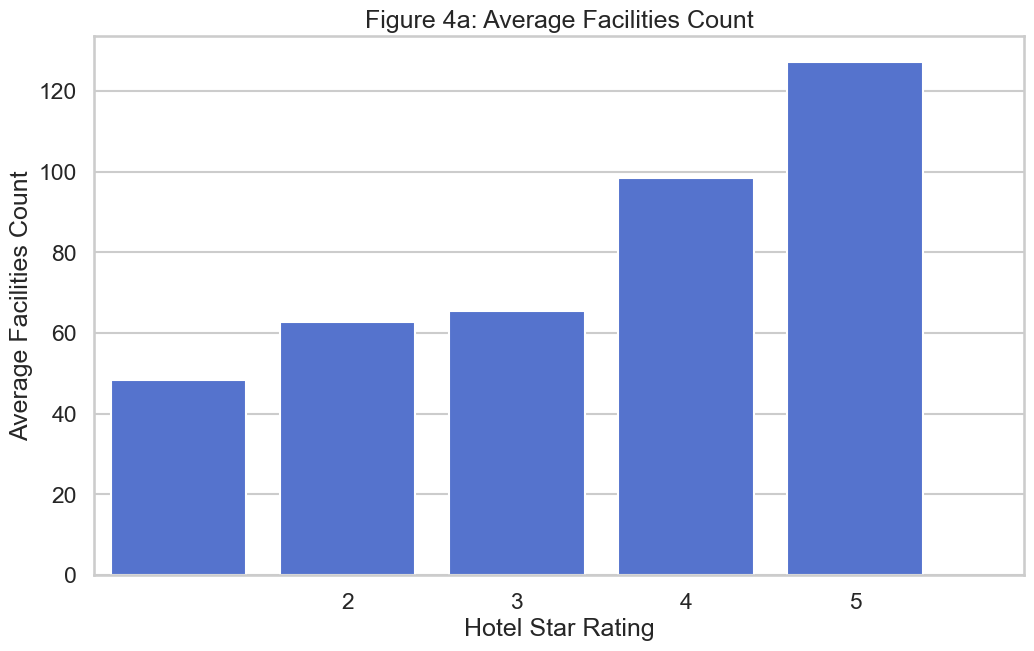

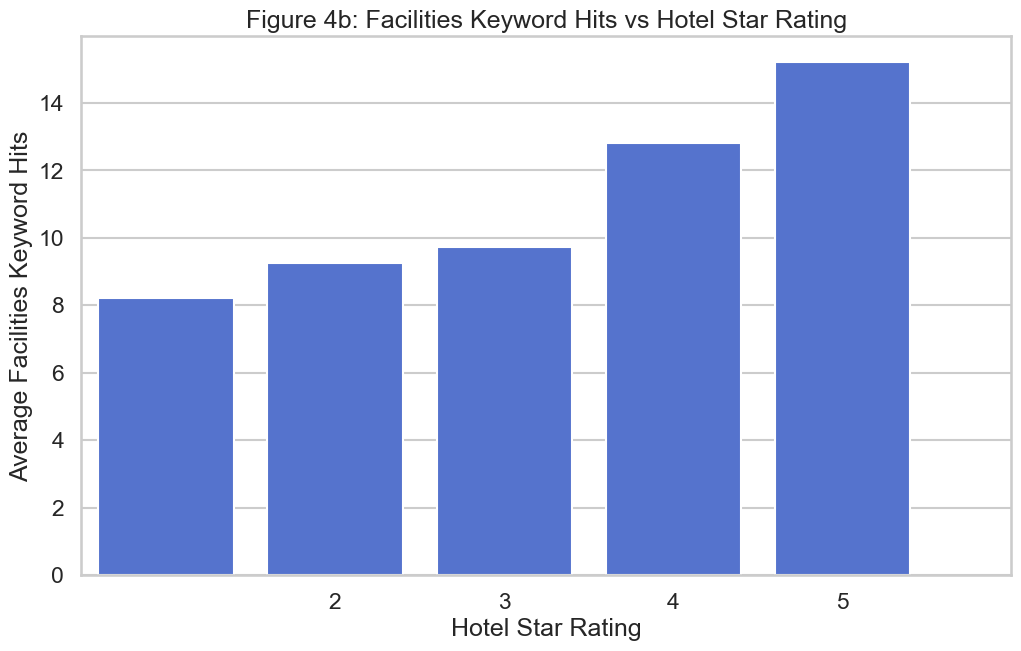

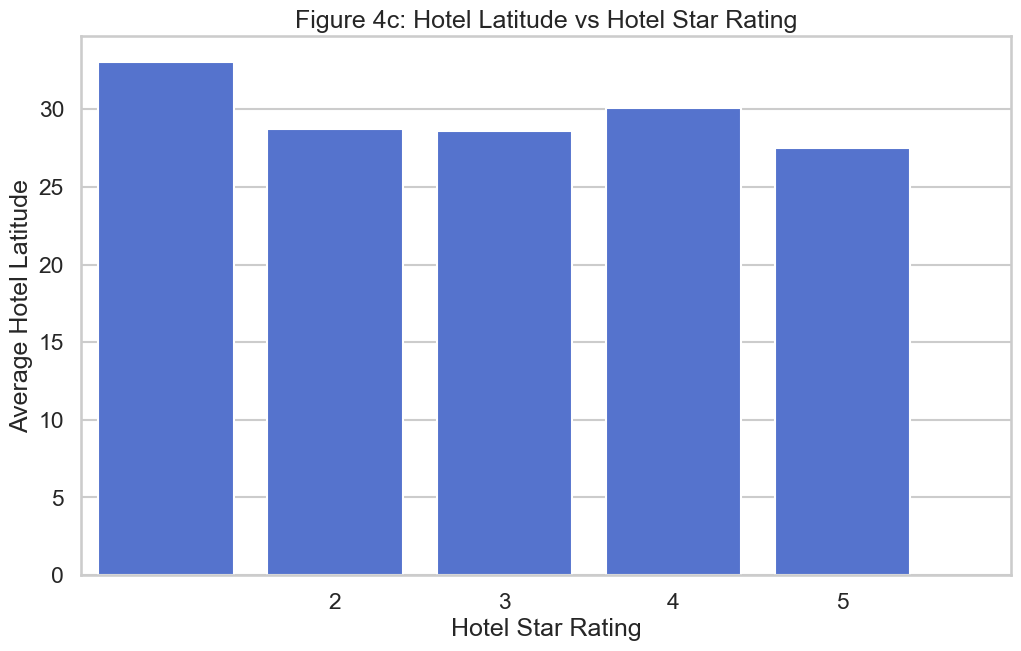

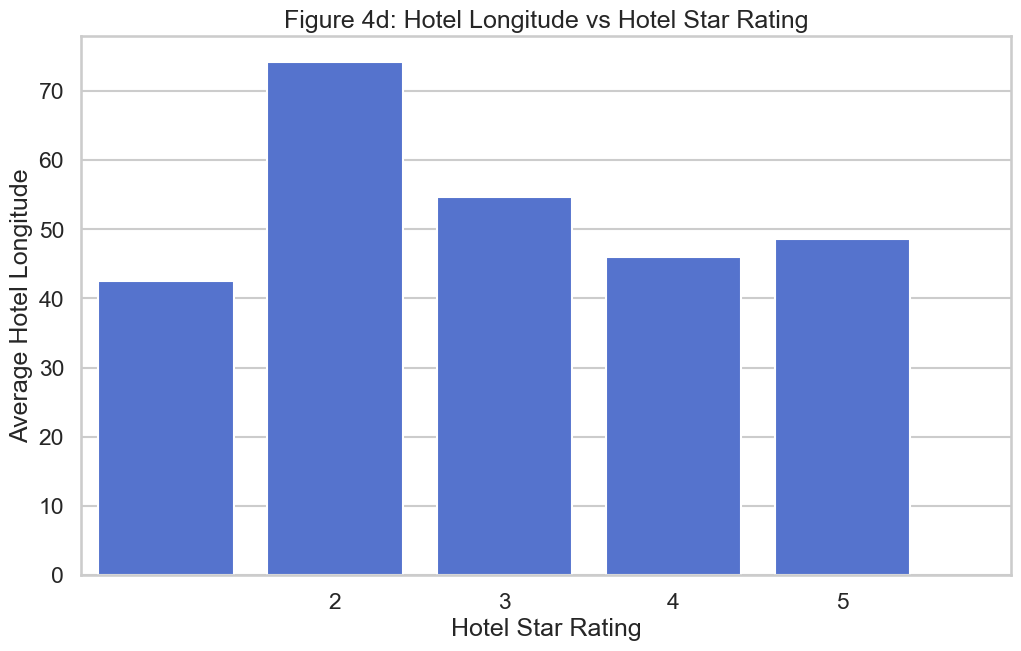

In [22]:
# Figure 4
plt.figure()
sns.barplot(data=df, x='hotel_star_rating', y='facilities_count', estimator=np.mean, errorbar=None, color='royalblue')
plt.title('Figure 4a: Average Facilities Count')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel('Hotel Star Rating')
plt.ylabel('Average Facilities Count')


# Figure 4.b
plt.figure()
sns.barplot(data=df, x='hotel_star_rating', y='facilities_keyword_hits', estimator=np.mean, errorbar=None, color='royalblue')
plt.title('Figure 4b: Facilities Keyword Hits vs Hotel Star Rating')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel('Hotel Star Rating')
plt.ylabel('Average Facilities Keyword Hits')

# Figure 4.c
plt.figure()
sns.barplot(data=df, x='hotel_star_rating', y='hotel_latitude', estimator=np.mean, errorbar=None, color='royalblue')
plt.title('Figure 4c: Hotel Latitude vs Hotel Star Rating')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel('Hotel Star Rating')
plt.ylabel('Average Hotel Latitude')

# Figure 4.d
plt.figure()
sns.barplot(data=df, x='hotel_star_rating', y='hotel_longitude', estimator=lambda x: np.mean(np.abs(x)), errorbar=None, color='royalblue')
plt.title('Figure 4d: Hotel Longitude vs Hotel Star Rating')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel('Hotel Star Rating')
plt.ylabel('Average Hotel Longitude')
plt.show()

plt.show()

### Interpretation — Figure 5

Geographic analysis reveals significant variance at national level. **Figure 5:** Yemen and Qatar lead the top countries with averages near 4.0.

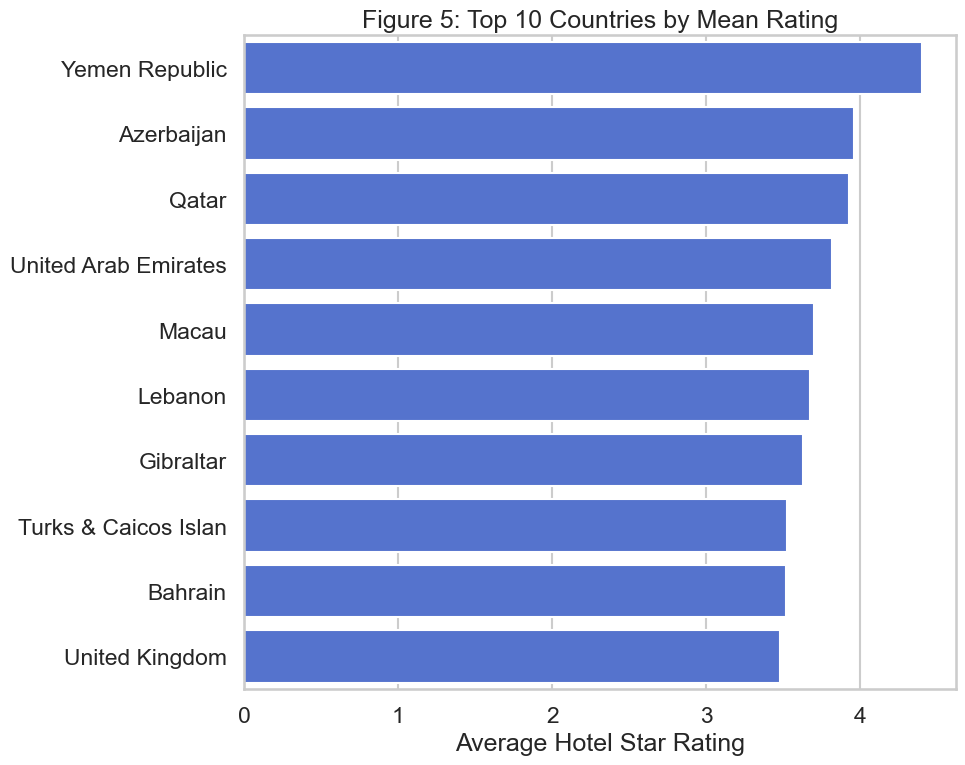

In [23]:
# Figure 5: Top 10 Countries (Horizontal)
plt.figure(figsize=(10, 8))
sns.barplot(y=top_10_countries.index, x=top_10_countries.values, color='royalblue', orient='h')
plt.title('Figure 5: Top 10 Countries by Mean Rating')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.show()


### Interpretation — Figure 5b

**Figure 5b:** Major markets like the United States and South Korea fall into the bottom ten with averages between 2.4 and 2.6.

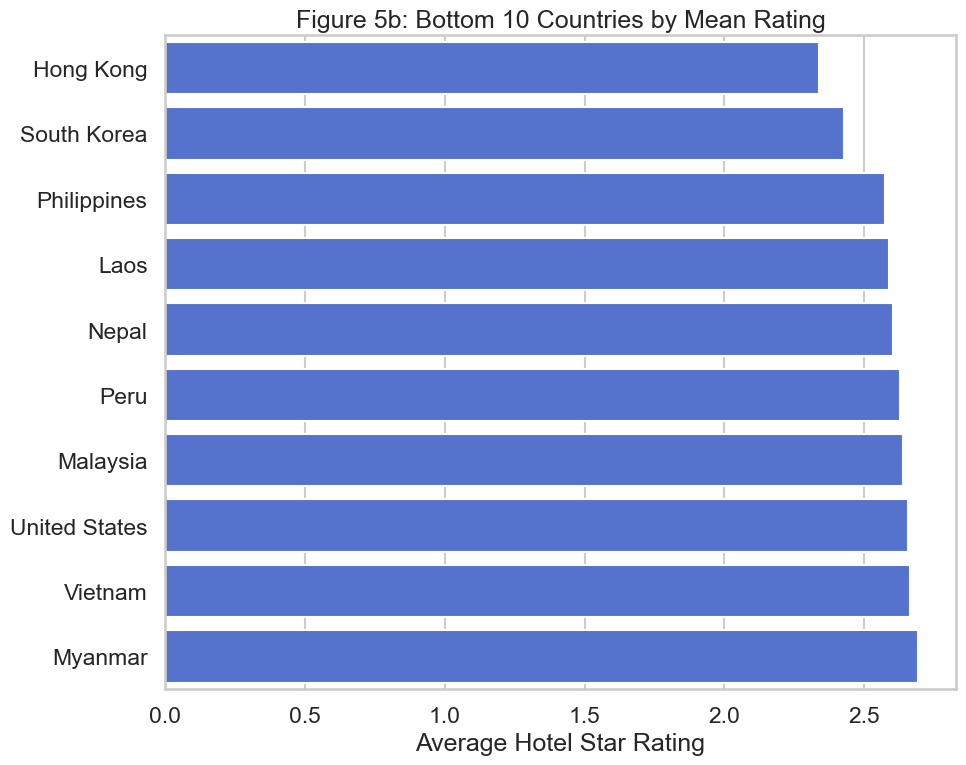

In [24]:
# Figure 5b: Worst 10 Countries (Horizontal)
plt.figure(figsize=(10, 8))
sns.barplot(y=worst_10_countries.index, x=worst_10_countries.values, color='royalblue', orient='h')
plt.title('Figure 5b: Bottom 10 Countries by Mean Rating')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.show()


### Interpretation — Figure 5c

**Figure 5c:** At the city level, Germany dominates the top performers with several cities averaging above 4.8.

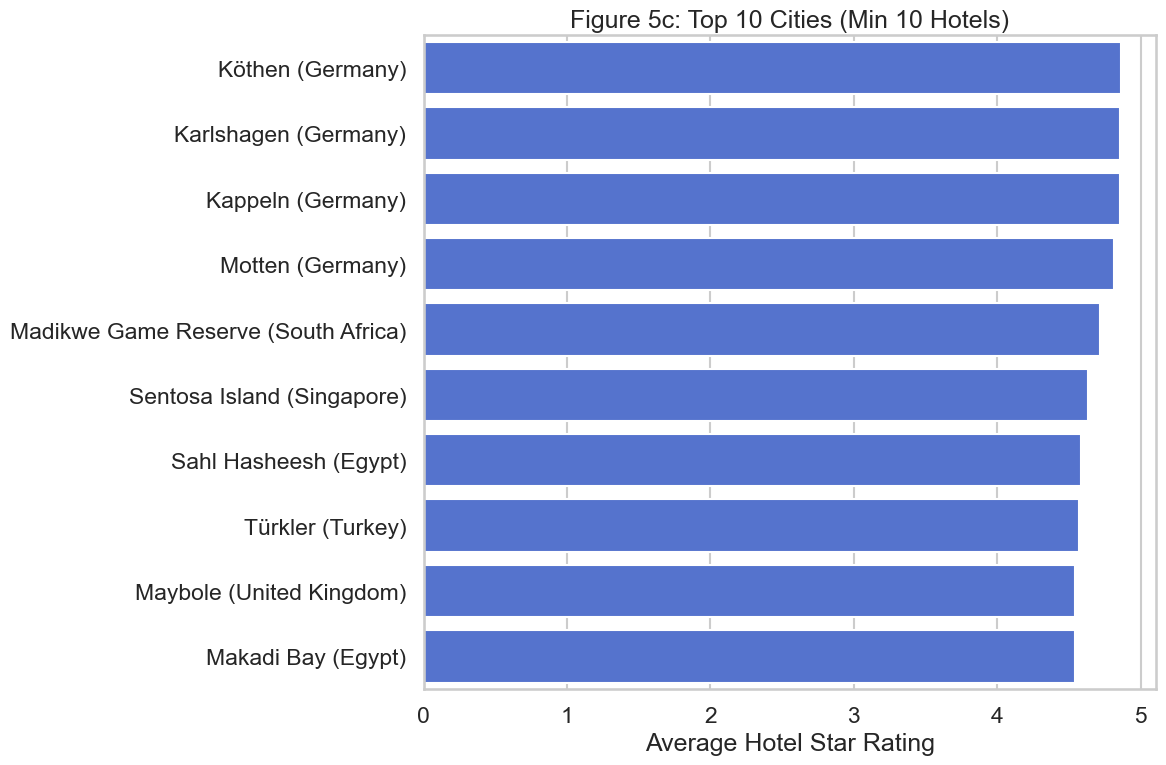

In [25]:
# Figure 5c: Top 10 Cities (Horizontal)
plt.figure(figsize=(12, 8))
sns.barplot(y=top_10_cities['city_label'], x=top_10_cities['mean'], color='royalblue', orient='h')
plt.title('Figure 5c: Top 10 Cities (Min 10 Hotels)')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.show()


### Interpretation — Figure 5d

**Figure 5d:** France accounts for the majority of the bottom ten cities, with several locations averaging below 1.5 stars.

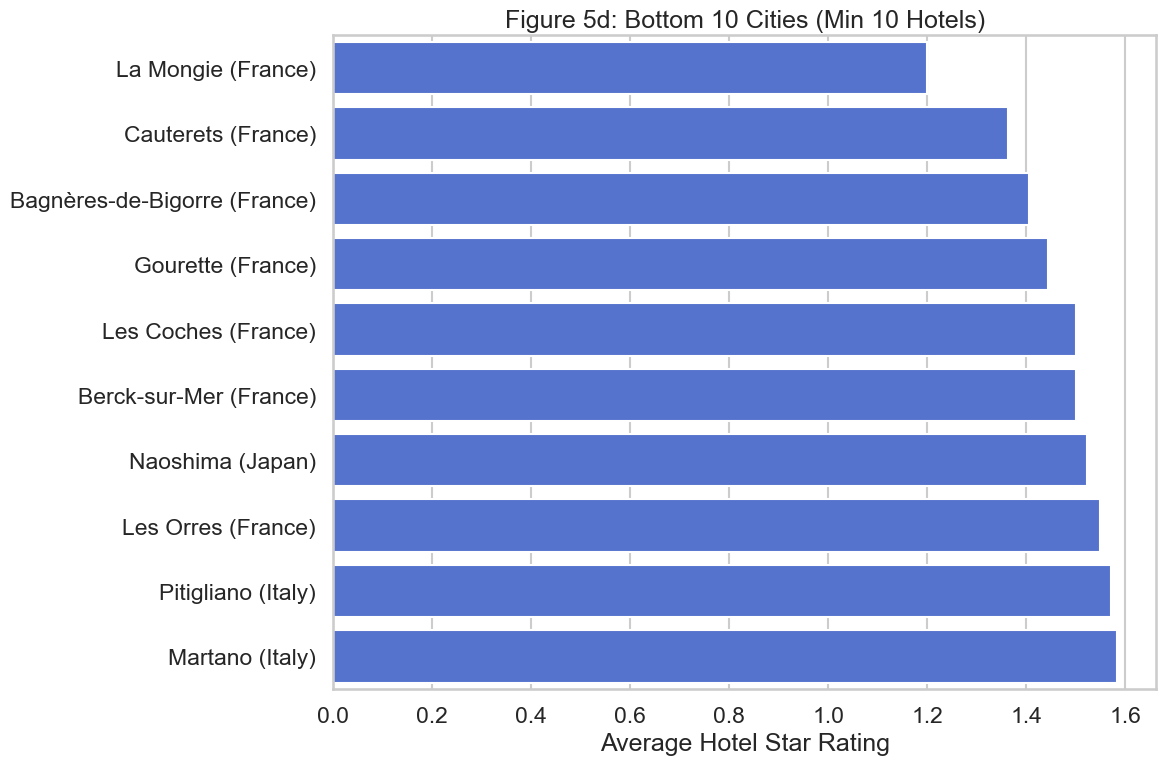

In [26]:
# Figure 5d: Worst 10 Cities (Horizontal)
plt.figure(figsize=(12, 8))
sns.barplot(y=worst_10_cities['city_label'], x=worst_10_cities['mean'], color='royalblue', orient='h')
plt.title('Figure 5d: Bottom 10 Cities (Min 10 Hotels)')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.show()


### Interpretation — Figure 6a

**Figure 6a:** Mean rating varies across sub-regions; this finer geography sets up the continent-level comparison in Figure 6b.

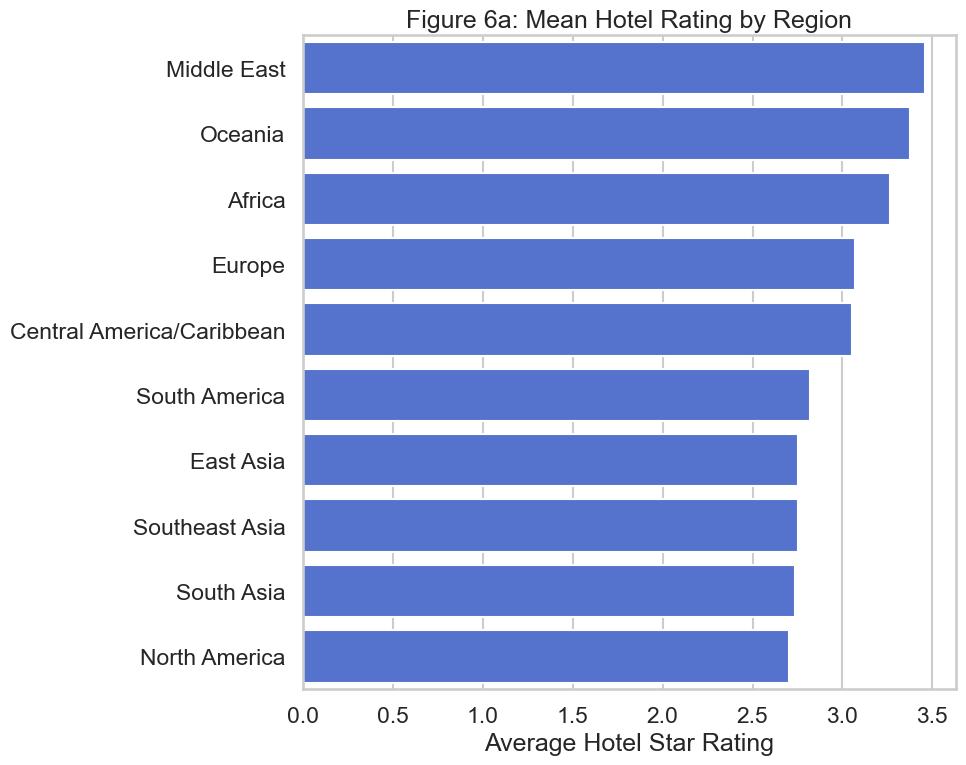

In [27]:
# Figure 6a: Sub-Region (Horizontal)
plt.figure(figsize=(10, 8))
sns.barplot(y=sub_region_stats.index, x=sub_region_stats.values, color='royalblue', orient='h')
plt.title('Figure 6a: Mean Hotel Rating by Region')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.show()


### Interpretation — Figure 6b

**Figure 6b:** Regionally, the Middle East maintains the highest average at 3.46, while North America sits at the bottom with 2.70. These results demonstrate that while broad regions hover near a 3.0 average, specific countries and cities exhibit extreme diversity in hotel standards (see Figures 5–6a).

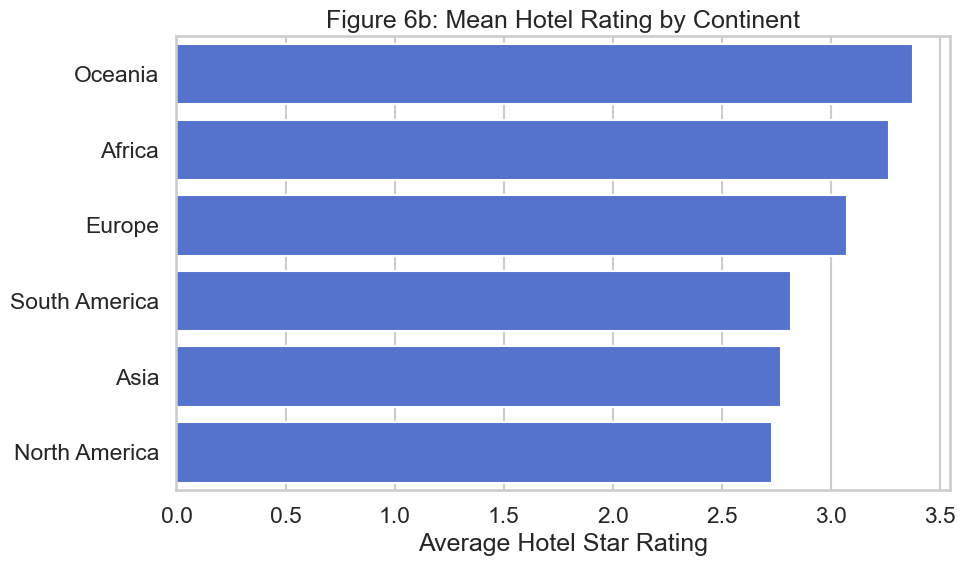

In [28]:
# Figure 6b: Rating by Continent
plt.figure(figsize=(10, 6))
sns.barplot(y=continent_stats.index, x=continent_stats.values, color='royalblue', orient='h')
plt.title('Figure 6b: Mean Hotel Rating by Continent')
plt.xlabel('Average Hotel Star Rating')
plt.ylabel('')
plt.tight_layout()
plt.show()


### Interpretation — Figure 6c
**Figure 6b:** Next, we examined the coordinate-based map to visualize the spatial distribution of hotel quality across the globe. We performed this mapping to identify if geographical location influences ratings beyond simple numerical coordinates.The global mapping reveals distinct regional patterns in hotel quality. Higher-rated cities are notably clustered within Europe, Oceania, and Africa, where average ratings are consistently stronger. In contrast, North America, South America, and Asia exhibit a higher concentration of lower average ratings. While raw latitude and longitude do not correlate linearly with quality, this visualization confirms that the broader regional context is a strong indicator of quality.

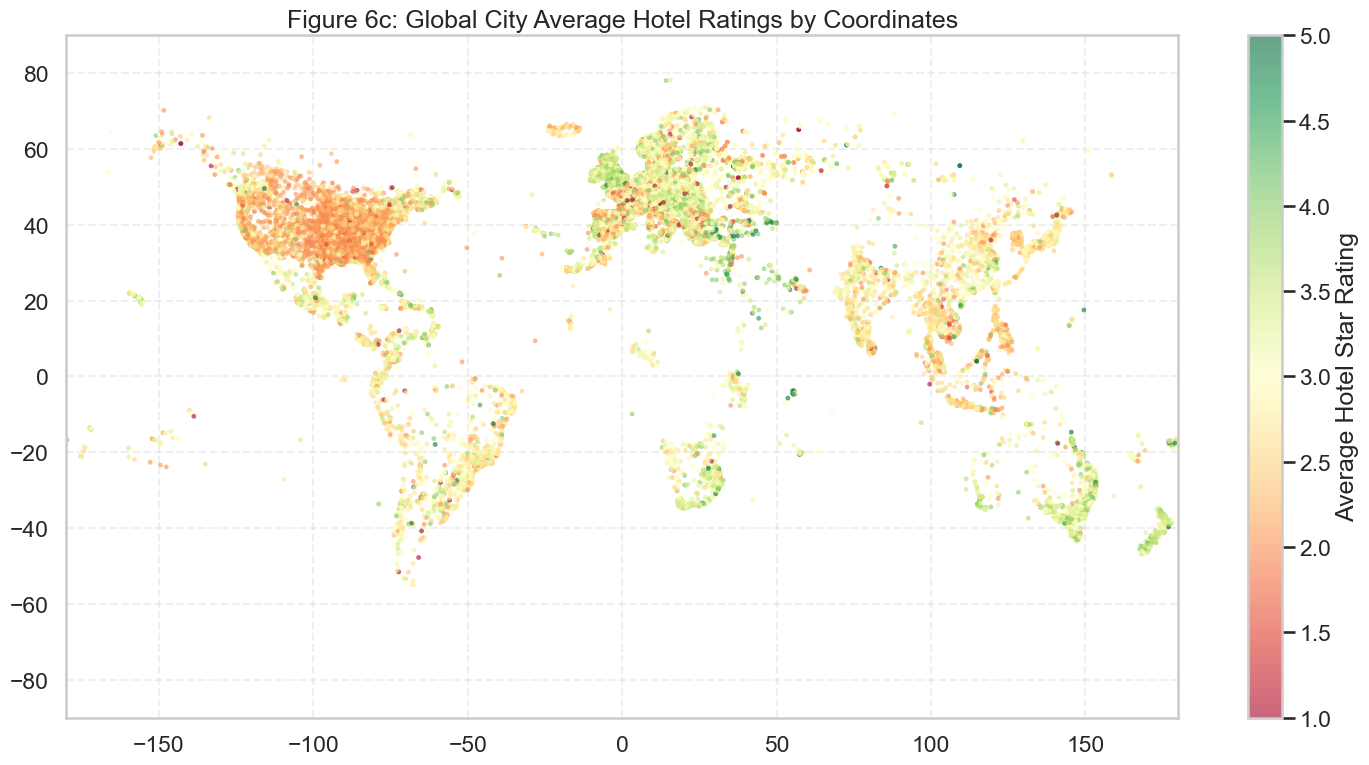

In [30]:
city_map_data = df.groupby(['cityName', 'countyName']).agg({
    'hotel_star_rating': 'mean',
    'hotel_latitude': 'mean',
    'hotel_longitude': 'mean'
}).dropna().reset_index()

plt.figure(figsize=(15, 8))
scatter = plt.scatter(
    city_map_data['hotel_longitude'], 
    city_map_data['hotel_latitude'], 
    c=city_map_data['hotel_star_rating'],
    cmap='RdYlGn',
    s=12,
    alpha=0.6,
    edgecolors='none'
)

plt.colorbar(scatter, label='Average Hotel Star Rating')

plt.title('Figure 6c: Global City Average Hotel Ratings by Coordinates')
plt.xlabel('')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.3)

plt.xlim(-180, 180)
plt.ylim(-90, 90)

plt.tight_layout()
plt.savefig('city_rating_coord_map.png')
plt.show()

plt.show()

### Interpretation — Figure 7

Next, we checked the heatmap to summarize the correlation between all numerical variables and identify which features have the most direct impact on hotel ratings. We perform this step to verify whether the visual trends observed in the previous charts are backed by statistical strength and to see if any hidden relationships exist between the data points.

The results from the heatmap demonstrate that there is no strong trend between hotel ratings and external factors. The only notable relationships involve facilities_keyword_hits (0.23) and facilities_count (0.21). This confirms that hotels with more listed facilities naturally trigger more keyword matches. In contrast, city population, attraction density, and coordinates show near-zero correlation, proving that hotel quality is independent of geographical and urban settings.

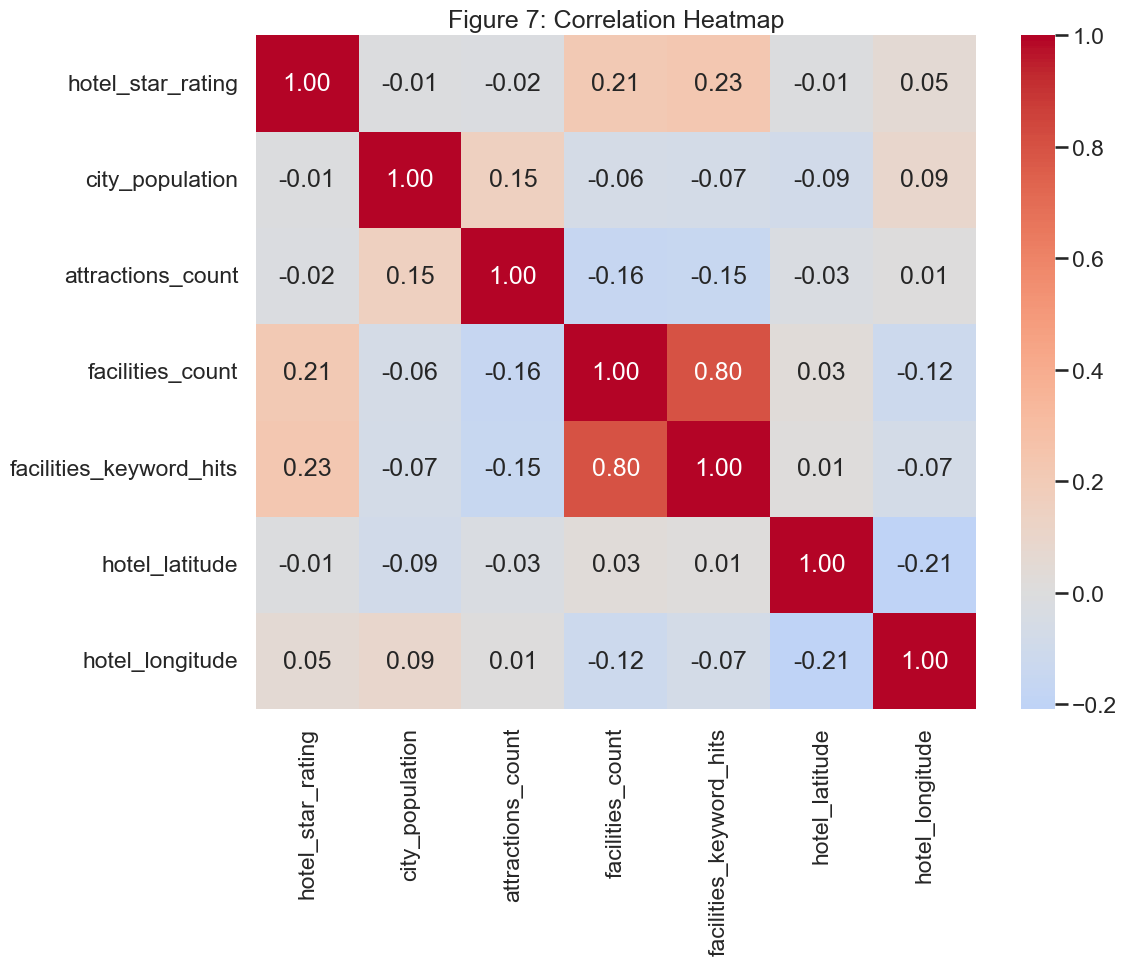

In [29]:
# Heat Map
# Figure 7: Correlation
numeric_cols_all = [
    'hotel_star_rating', 
    'city_population', 
    'attractions_count', 
    'facilities_count',
    'facilities_keyword_hits',
    'hotel_latitude', 
    'hotel_longitude'
]

corr_all = df[numeric_cols_all].corr()

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_all, 
    annot=True, 
    cmap='coolwarm', 
    center=0, 
    fmt='.2f', 
    ax=ax
)

ax.set_title('Figure 7: Correlation Heatmap')
plt.tight_layout()

plt.show()

## Part 7: Expanded exploratory data analysis and visualizations


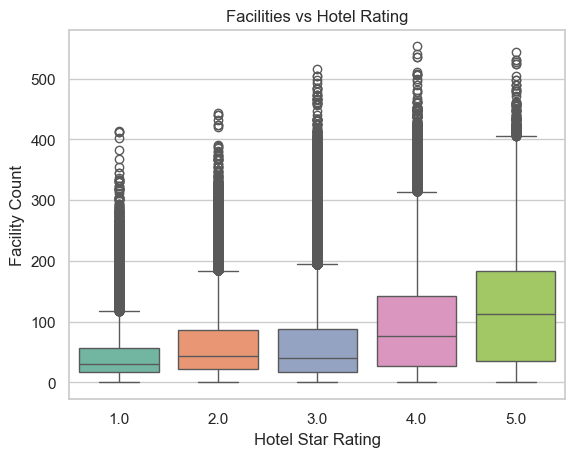

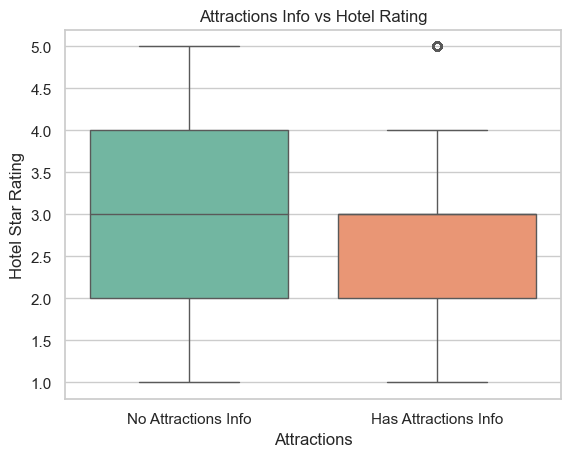

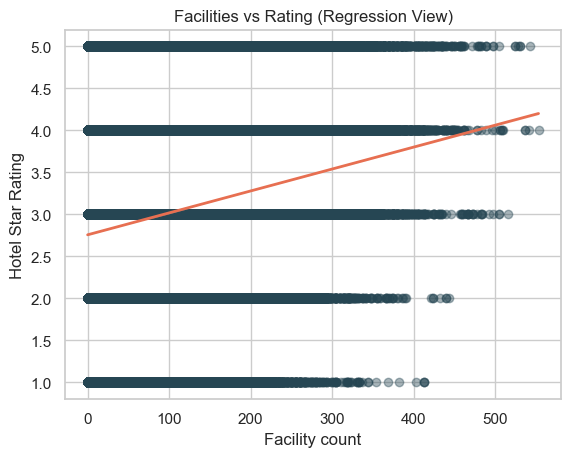

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Load raw data once
df = pd.read_csv("../data/raw/hotels.csv", encoding="latin-1")
df.columns = df.columns.str.strip()

rating_map = {
    "OneStar": 1,
    "TwoStar": 2,
    "ThreeStar": 3,
    "FourStar": 4,
    "FiveStar": 5,
}

df["hotel_star_rating"] = df["HotelRating"].map(rating_map)

df["facility_count"] = df["HotelFacilities"].fillna("").apply(lambda x: len(str(x).split()))
df["description_length"] = df["Description"].fillna("").apply(len)
df["has_attractions"] = df["Attractions"].notna().astype(int)

coords = df["Map"].str.split("|", expand=True)
df["latitude"] = pd.to_numeric(coords[0], errors="coerce")
df["longitude"] = pd.to_numeric(coords[1], errors="coerce")

# Save processed data as parquet
df.to_parquet("../data/processed/hotels_clean_expanded.parquet", index=False)

"""
These analyses expand upon our EDA by adding derived features,
effect sizes, non-parametric tests, regression checks, diagnostics,
and interpretation fields.
"""

# Load cleaned data
df = pd.read_parquet("../data/processed/hotels_clean_expanded.parquet")

# Convert hotel rating to numeric
rating_map = {
    "OneStar": 1,
    "TwoStar": 2,
    "ThreeStar": 3,
    "FourStar": 4,
    "FiveStar": 5,
}

df["hotel_star_rating"] = df["HotelRating"].map(rating_map)

# Create expanded EDA features
df["facility_count"] = df["HotelFacilities"].fillna("").apply(lambda x: len(str(x).split()))
df["description_length"] = df["Description"].fillna("").apply(len)
df["has_attractions"] = df["Attractions"].notna().astype(int)

# Optional: split map into latitude/longitude safely
coords = df["Map"].str.split("|", expand=True)

df["latitude"] = pd.to_numeric(coords[0], errors="coerce")
df["longitude"] = pd.to_numeric(coords[1], errors="coerce")


# Effect size analysis
def _effect_size_analysis(high_group, low_group) -> dict[str, float]:
    n1, n2 = len(high_group), len(low_group)
    var1, var2 = high_group.var(ddof=1), low_group.var(ddof=1)

    pooled_sd = np.sqrt(
        ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    )

    cohens_d = (high_group.mean() - low_group.mean()) / pooled_sd

    return {
        "cohens_d": float(cohens_d),
    }


# Non-parametric test alongside the t-test
def _nonparametric_test(high_group, low_group) -> dict[str, float | str]:
    u_stat, p_value = mannwhitneyu(
        high_group,
        low_group,
        alternative="two-sided"
    )

    return {
        "test": "Mann–Whitney U",
        "u_statistic": float(u_stat),
        "p_value": float(p_value),
    }


# Lightweight regression block
def _regression_test(df, feature, target) -> dict[str, float | str | int]:
    test_df = df.dropna(subset=[feature, target])

    X = sm.add_constant(test_df[feature])
    y = test_df[target]

    model = sm.OLS(y, X).fit()

    return {
        "test": "OLS regression",
        "n": int(len(test_df)),
        "coefficient": float(model.params[feature]),
        "p_value": float(model.pvalues[feature]),
        "r_squared": float(model.rsquared),
    }


# Interpretation fields
def _interpret_p(p: float) -> str:
    if p < 0.01:
        return "strong evidence against null"
    elif p < 0.05:
        return "moderate evidence against null"
    else:
        return "no significant evidence"


def _interpret_effect_size(d: float) -> str:
    d = abs(d)

    if d < 0.2:
        return "negligible"
    elif d < 0.5:
        return "small"
    elif d < 0.8:
        return "medium"
    else:
        return "large"


# Feature diagnostics
def _feature_diagnostics(df, feature) -> dict[str, float | int]:
    return {
        "skewness": float(df[feature].skew()),
        "unique_values": int(df[feature].nunique()),
        "missing_values": int(df[feature].isna().sum()),
    }

sns.set_theme(style="whitegrid", palette="Set2")
df["attractions_label"] = df["has_attractions"].map({
    0: "No Attractions Info",
    1: "Has Attractions Info"
})

sns.boxplot(
    x="hotel_star_rating",
    y="facility_count",
    data=df,
    palette="Set2" 
)
plt.title("Facilities vs Hotel Rating")
plt.xlabel("Hotel Star Rating")
plt.ylabel("Facility Count")
plt.show()


sns.boxplot(
    x="attractions_label",
    y="hotel_star_rating",
    data=df,
    palette="Set2"
)
plt.title("Attractions Info vs Hotel Rating")
plt.xlabel("Attractions")
plt.ylabel("Hotel Star Rating")
plt.show()

sns.regplot(
    x="facility_count",
    y="hotel_star_rating",
    data=df,
    scatter_kws={
        "alpha": 0.4,
        "color": "#264653"   # dark blue/teal
    },
    line_kws={
        "color": "#e76f51",  # strong contrast (reddish)
        "linewidth": 2
    }
)
plt.title("Facilities vs Rating (Regression View)")
plt.xlabel("Facility count")
plt.ylabel("Hotel Star Rating")
plt.show()


### Interpretations of figures:

**Facilities vs Hotel Ratings:** 
Higher-rated hotels generally tend to offer a greater number of facilities, as reflected in the rising median and wider spread across increasing star ratings. However, while there is a positive relationship between the number of facilities and a hotel’s rating, facilities alone do not fully determine that rating. This is evident in the considerable overlap between certain categories—particularly among 3- and 4-star hotels. Despite this overlap, the distinction becomes more pronounced at the extremes, where the highest- and lowest-rated hotels show a clearer correlation between rating and the range of facilities offered.

**Facilities vs Rating (Regression View):**
The graph shows a clear positive relationship between facility count and hotel star rating, with higher-rated hotels generally offering more facilities. However, there is substantial overlap between mid-range ratings (especially 3- and 4-star hotels), indicating that facility count alone does not fully determine a hotel’s rating. The distinction is more evident at the extremes, where 1-star hotels tend to have fewer facilities and 5-star hotels consistently have the highest counts.

**Attractions Info vs Hotel Rating:**
There is no meaningful difference in rating distributions between hotels with and without attractions information, as the median ratings for both groups are nearly identical. The substantial overlap between the distributions further suggests that this feature does not effectively distinguish between higher- and lower-rated hotels. Instead, the presence of attractions information appears to reflect the level of listing detail rather than the actual quality of the hotel. As a result, it is unlikely to be a useful predictor in modeling hotel ratings—especially when compared to the number of facilities, which shows a much stronger correlation with ratings.


**Key Takeaways:**
Overall, the facility count may be a useful predictor in modeling hotel ratings, while attractions information likely provides limited predictive value.

